## Empleo de Algoritmos Clásicos de Machine Learning en Imágenes

In [1]:
!pip install scikit-learn
!pip install pandas

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 4.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.1 MB 6.4 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.1 MB 6.4 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 3.7 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.7 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 3.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 3.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 3.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 3.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 3.0 MB/s eta 0:00:01
   ---------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


^C


In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

# Las imagenes son de tamaño 28x28.
# Pero las imágenes ya vienen desdobladas en vectores (28x28=784)
# Son 70k imágenes

print(f"Forma de los datos: {X.shape}")
print(f"Estructura de las etiquetas: {y.shape}")
X = X[:10000]
y = y[:10000]

print(f"Forma reducida de los datos: {X.shape}")
print(f"Estructura reducida de las etiquetas: {y.shape}")

Forma de los datos: (70000, 784)
Estructura de las etiquetas: (70000,)
Forma reducida de los datos: (10000, 784)
Estructura reducida de las etiquetas: (10000,)


Etiqueta de la imagen: 9


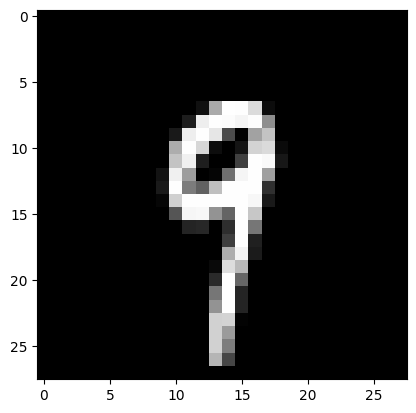

In [3]:
# Por ejemplo, se muestra la imagen 1:

imagen = X[600].reshape(28,28)
etiqueta = y[600]

print(f"Etiqueta de la imagen: {etiqueta}")
plt.imshow(imagen, cmap="gray")
plt.show()

In [4]:
# Se seleccionan los grupos de imagenes y etiquetas para el entrenamiento
# y las pruebas. No se debe probar con el mismo grupo de entrenamiento (sesgos).
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)

In [5]:
# Tomo sólo un grupo de datos. Si usamos todos tardará tiempo considerable 
# en el entrenamiento y predicción

X_train = X_train
y_train = y_train

X_test = X_test
y_test = y_test

In [6]:
len(X_train)

8000

In [ ]:
# Uso de máquinas de soporte vectorial (SVM) para clasificación

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

modelos = {
    "SVM": LinearSVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=5)
}

resultados = {}
for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    resultados[nombre] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1
    }
    
    print(f"{nombre}")
    rp = classification_report(y_test, y_pred)
    print("\nReporte de clasificación del modelo:\n")
    print(rp)

Entrenando SVM...


c:\VisionArtificial\ExU3\entornoEU3\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVM

Reporte de clasificación del mejor modelo:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       201
           1       0.95      0.93      0.94       223
           2       0.83      0.78      0.80       197
           3       0.86      0.78      0.82       213
           4       0.91      0.90      0.90       192
           5       0.75      0.85      0.80       171
           6       0.94      0.90      0.92       201
           7       0.87      0.86      0.86       211
           8       0.75      0.82      0.79       194
           9       0.81      0.81      0.81       197

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Entrenando KNN...
KNN

Reporte de clasificación del mejor modelo:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       201
           1    

In [8]:
mejor_modelo = max(resultados, key=lambda x: resultados[x]["f1_score"])
print(f"\nEl mejor modelo fue: {mejor_modelo}")


El mejor modelo fue: Random Forest
